## Phase 2 — Transformer Encoder Autopsy

In this phase, we inspect the real pretrained ViT-Base model.

#### Data flow inside one encoder block

1. LayerNorm before attention
2. Query, Key, and Value projections
3. Multi-head self-attention
4. Attention output projection
5. First residual connection
6. LayerNorm before MLP
7. MLP expansion: 768 → 3072
8. GELU activation
9. MLP contraction: 3072 → 768
10. Second residual connection

The sequence shape remains `[B, 197, 768]` throughout the block.

In [1]:
import math
import torch
import torch.nn.functional as F
from transformers import AutoImageProcessor, ViTForImageClassification

import matplotlib.pyplot as plt
from PIL import Image, ImageDraw

In [2]:
MODEL_ID = "google/vit-base-patch16-224"
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

processor = AutoImageProcessor.from_pretrained(MODEL_ID)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:138: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
  warnings.warn(f"\nError while fetching `HF_TOKEN` secret value from your vault: '{str(e)}'.")


preprocessor_config.json:   0%|          | 0.00/160 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/69.7k [00:00<?, ?B/s]

**Load Model**

In [3]:
model = ViTForImageClassification.from_pretrained(
    MODEL_ID,
    attn_implementation="eager"
).to(device)

model.eval()
print("Device:", device)

model.safetensors: reconstructing file:   0%|          |  0.00B /  346MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

Device: cuda


**Configuration X-ray**

In [4]:
config = model.config

print("Model type             :", config.model_type)
print("Image size             :", config.image_size)
print("Patch size             :", config.patch_size)
print("Hidden size            :", config.hidden_size)
print("Encoder blocks         :", config.num_hidden_layers)
print("Attention heads        :", config.num_attention_heads)
print("Intermediate/MLP size  :", config.intermediate_size)
print("Number of output labels:", config.num_labels)
print("Hidden activation      :", config.hidden_act)

Model type             : vit
Image size             : 224
Patch size             : 16
Hidden size            : 768
Encoder blocks         : 12
Attention heads        : 12
Intermediate/MLP size  : 3072
Number of output labels: 1000
Hidden activation      : gelu


In [5]:
head_dimension = (
    config.hidden_size // config.num_attention_heads
)

num_of_patches = (
    config.image_size // config.patch_size
) ** 2

total_tokens = num_of_patches + 1

print("Head dimension :", head_dimension)
print("Patch tokens   :", num_of_patches)
print("Total tokens   :", total_tokens)

Head dimension : 64
Patch tokens   : 196
Total tokens   : 197


**Parameter count**

In [6]:
total_parameters = sum(
    parameter.numel()
    for parameter in model.parameters()
)

trainable_parameters = sum(
    parameter.numel()
    for parameter in model.parameters()
    if parameter.requires_grad
)

print(f"Total parameters    : {total_parameters:,}")
print(f"Trainable parameters: {trainable_parameters:,}")

Total parameters    : 86,567,656
Trainable parameters: 86,567,656


#### Part B — Real patch projection inspect

**Patch projection layer**

In [7]:
patch_projection = (
    model.vit.embeddings.patch_embeddings.projection
)

print(patch_projection)
print("Weight shape:", patch_projection.weight.shape)
print("Bias shape:", patch_projection.bias.shape)

Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
Weight shape: torch.Size([768, 3, 16, 16])
Bias shape: torch.Size([768])


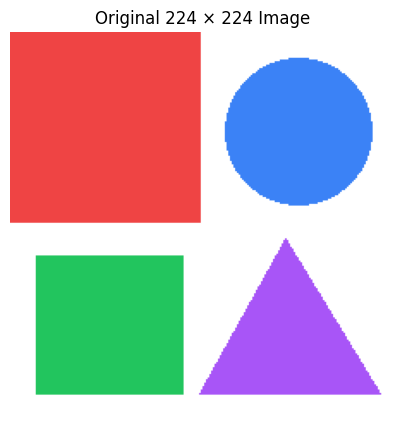

In [8]:
image = Image.new("RGB", (224, 224), color="white")
draw = ImageDraw.Draw(image)

draw.rectangle((0, 0, 110, 110), fill=(239, 68, 68))
draw.ellipse((125, 15, 210, 100), fill=(59, 130, 246))
draw.rectangle((15, 130, 100, 210), fill=(34, 197, 94))
draw.polygon(
    [(160, 120), (215, 210), (110, 210)],
    fill=(168, 85, 247)
)

plt.figure(figsize=(5, 5))
plt.imshow(image)
plt.title("Original 224 × 224 Image")
plt.axis("off")
plt.show()

_prepare image with image_

In [9]:
inputs = processor(
    images=image,
    return_tensors="pt"
)

pixel_values = inputs["pixel_values"].to(device)

print("Processed pixel tensor:", pixel_values.shape)
print("Minimum value:", pixel_values.min().item())
print("Maximum value:", pixel_values.max().item())

Processed pixel tensor: torch.Size([1, 3, 224, 224])
Minimum value: -0.7333333492279053
Maximum value: 1.0


_Run Conv2d projection_

In [10]:
with torch.no_grad():
    projection_output = patch_projection(pixel_values)
    
print("Projection output:", projection_output.shape)

Projection output: torch.Size([1, 768, 14, 14])


_Spatial grid to token sequence_

In [11]:
manual_patch_tokens = (
    projection_output.flatten(2).transpose(1, 2)
)

print("After flatten + transpose:", manual_patch_tokens.shape)

After flatten + transpose: torch.Size([1, 196, 768])


_CLS and position embedding_

In [12]:
cls_token = model.vit.embeddings.cls_token
position_embeddings = (
    model.vit.embeddings.position_embeddings
)

print("CLS token shape         :", cls_token.shape)
print("Position embedding shape:", position_embeddings.shape)

CLS token shape         : torch.Size([1, 1, 768])
Position embedding shape: torch.Size([1, 197, 768])


_Full embedding module_

In [13]:
with torch.no_grad():
    embedding_output = model.vit.embeddings(pixel_values)
    
print("Transformer input:", embedding_output.shape)

Transformer input: torch.Size([1, 197, 768])


#### Part C — Inspect first transformer block

In [14]:
if hasattr(model.vit, "encoder"):
    blocks = model.vit.encoder.layer
else:
    blocks = model.vit.layers

first_block = blocks[0]
print(first_block)

ViTLayer(
  (attention): ViTAttention(
    (q_proj): Linear(in_features=768, out_features=768, bias=True)
    (k_proj): Linear(in_features=768, out_features=768, bias=True)
    (v_proj): Linear(in_features=768, out_features=768, bias=True)
    (o_proj): Linear(in_features=768, out_features=768, bias=True)
  )
  (layernorm_before): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
  (layernorm_after): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
  (mlp): ViTMLP(
    (activation_fn): GELUActivation()
    (fc1): Linear(in_features=768, out_features=3072, bias=True)
    (fc2): Linear(in_features=3072, out_features=768, bias=True)
  )
  (dropout): Dropout(p=0.0, inplace=False)
)


#### Part D — Q, K, V shape inspection

In [15]:
with torch.no_grad():
    normalized_tokens = first_block.layernorm_before(
        embedding_output
    )
    
print("Before LayerNorm:", embedding_output.shape)
print("After LayerNorm :", normalized_tokens.shape)

Before LayerNorm: torch.Size([1, 197, 768])
After LayerNorm : torch.Size([1, 197, 768])


**Q, K and V projection**

In [16]:
self_attention = first_block.attention

with torch.no_grad():
    query = self_attention.q_proj(normalized_tokens)
    key = self_attention.k_proj(normalized_tokens)
    value = self_attention.v_proj(normalized_tokens)
    
print("Query:", query.shape)
print("Key  :", key.shape)
print("Value:", value.shape)

Query: torch.Size([1, 197, 768])
Key  : torch.Size([1, 197, 768])
Value: torch.Size([1, 197, 768])


_reshape 12 head_

In [18]:
batch_size, token_count, hidden_size = query.shape

num_of_heads = config.num_attention_heads
head_dimension = hidden_size // num_of_heads

def split_into_heads(tensor):
    tensor = tensor.view(
        batch_size, token_count,
        num_of_heads, head_dimension
    )
    return tensor.permute(0, 2, 1, 3)

query_heads = split_into_heads(query)
key_heads = split_into_heads(key)
value_heads = split_into_heads(value)

print("Query heads:", query_heads.shape)
print("Key heads  :", key_heads.shape)
print("Value heads:", value_heads.shape)

Query heads: torch.Size([1, 12, 197, 64])
Key heads  : torch.Size([1, 12, 197, 64])
Value heads: torch.Size([1, 12, 197, 64])


#### Part E — Scaled Dot-Product Attention

**Attention scores**